In [90]:
import os
from google.colab import drive

# 1. Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# 2. Set the notebook's root path to the directory containing your 'Data' folder
# Based on your input, the parent directory of '/content/drive/MyDrive/A Web of Indicators/Data' is '/content/drive/MyDrive/A Web of Indicators/'
notebook_root_path = '/content/drive/MyDrive/A Web of Indicators/'

if os.path.exists(notebook_root_path):
    os.chdir(notebook_root_path)
    print(f"Changed current working directory to: {os.getcwd()}")
else:
    print(f"Warning: Notebook root path '{notebook_root_path}' not found. Please ensure the path is correct.")
    print("You may need to manually navigate to your notebook's location in Google Drive and verify the parent folder of your 'Data' directory.")

data_directory = './Data' # Now this path is relative to the notebook's root path

# Check if the Data directory exists and list its contents
if os.path.exists(data_directory) and os.path.isdir(data_directory):
    files_in_data = os.listdir(data_directory)
    if files_in_data:
        print(f"Files found in '{data_directory}':")
        for file_name in files_in_data:
            print(file_name)
    else:
        print(f"The directory '{data_directory}' is empty. Please ensure your data files are placed here.")
else:
    print(f"The directory '{data_directory}' does not exist at the specified path. Please create it and upload your data files.")


Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Changed current working directory to: /content/drive/MyDrive/A Web of Indicators
Files found in './Data':
u,gdp,gdpc,cpi.csv
india_yield.xlsx
usa_wpi.csv
india_wpi.gsheet
india_wpi - india_wpi.csv
usa_yield.csv
india_yield.csv
informal-economy-database.xlsx
informal.csv
india_u.gsheet
india_u.csv
gdp.csv


### Note on GitHub Accessibility

While the previous cell sets up the environment to correctly read data from your Google Drive, please remember that this local drive path will not be accessible to others if you share this notebook on GitHub. For a truly self-contained and universally runnable notebook on GitHub, you would typically:

1.  **Host your data publicly** (e.g., on Kaggle, a public S3 bucket, or a dedicated data repository) and include code to download it programmatically into the `./Data` directory.
2.  **Commit the `Data` folder** containing all necessary CSV files directly into your GitHub repository alongside the `.ipynb` file. Users would then clone the repo and have the data locally.

# Economic Indicator Analysis: USA vs India

This section consolidates the loading, cleaning, and merging of all indicators including Unemployment, GDP, CPI, WPI, Yields, and Informal Economy data.

In [91]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Helper function to clean indicator labels
def clean_indicator_label(label):
    label = label.replace('_', ' ')
    label = label.replace('Annual Average WPI', 'WPI')
    return label

# 1. Load Primary IMF Dataset
uggc = pd.read_csv("./Data/u,gdp,gdpc,cpi.csv")

# Helper to extract and format IMF series
def extract_imf(df, row_idx, name):
    s = df.iloc[row_idx, 7:].to_frame(name=name).T
    s.columns = s.columns.astype(int)
    s = s.T
    s.index.name = 'year'
    return s

# Extract USA
usa_u_df = extract_imf(uggc, 0, 'Unemployment Rate')
usa_gdpc_df = extract_imf(uggc, 1, 'GDP Per Capita')
usa_cpi_df = extract_imf(uggc, 2, 'CPI')
usa_gdp_df = extract_imf(uggc, 3, 'GDP Growth')

# Extract India (Base data)
india_gdpc_df = extract_imf(uggc, 7, 'GDP Per Capita')
india_cpi_df = extract_imf(uggc, 4, 'CPI')
india_gdp_df = extract_imf(uggc, 5, 'GDP Growth')

In [92]:
# 2. Load and Process India Unemployment (New File)
india_u_raw = pd.read_csv('./Data/india_u.csv', sep=None, engine='python', on_bad_lines='skip')
india_u_df = india_u_raw.drop(columns=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'])
india_u_df = india_u_df.melt(var_name='year', value_name='Unemployment Rate')
india_u_df['year'] = india_u_df['year'].astype(int)
india_u_df.set_index('year', inplace=True)

In [93]:
# 3. Load and Process WPI
# USA WPI
usa_wpi_raw = pd.read_csv("./Data/usa_wpi.csv")
usa_wpi_raw['observation_date'] = pd.to_datetime(usa_wpi_raw['observation_date'])
usa_wpi = usa_wpi_raw.groupby(usa_wpi_raw['observation_date'].dt.year)['PCUAWHLTRAWHLTR'].mean().to_frame('Annual_Average_WPI')
usa_wpi.index.name = 'year'

# India WPI
india_wpi_raw = pd.read_csv('./Data/india_wpi - india_wpi.csv')
india_wpi = india_wpi_raw.drop(columns=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']).melt(var_name='year', value_name='Annual_Average_WPI')
india_wpi['year'] = india_wpi['year'].astype(int)
india_wpi.set_index('year', inplace=True)

In [94]:
# 4. Load and Process Yields
# USA Yield
usa_yield_raw = pd.read_csv("./Data/usa_yield.csv")
usa_yield_raw['observation_date'] = pd.to_datetime(usa_yield_raw['observation_date'])
usa_yield_annual = usa_yield_raw.groupby(usa_yield_raw['observation_date'].dt.year)['DFII10'].mean().to_frame('Real Yield')
usa_yield_annual.index.name = 'year'

# India Yield
india_yield = pd.read_csv("./Data/india_yield.csv").iloc[:,0:3].drop('num_auctions', axis=1)
india_yield.rename(columns={'avg_yield_pct': 'Real Yield'}, inplace=True)
india_yield.set_index('year', inplace=True)

In [95]:
# 5. Load and Process Informal Economy
informal_data = pd.read_csv('./Data/informal.csv')

def process_informal(df, country_name):
    country_row = df[df['Economy'] == country_name].iloc[0, 1:].to_frame(name='Informal Economy').T
    country_row.columns = country_row.columns.astype(int)
    return country_row.T

usa_informal_df = process_informal(informal_data, 'United States')
india_informal_df = process_informal(informal_data, 'India')

In [96]:
import pandas as pd

# 5.b. Load and Process GDP from new gdp.csv
gdp_raw = pd.read_csv('./Data/gdp.csv', sep=None, engine='python', on_bad_lines='skip')

def process_gdp_file(df, country_name):
    # Clean up column names by stripping whitespace and potential BOM characters
    df.columns = df.columns.str.strip().str.replace('\ufeff', '')

    # Filter for the specific country
    country_gdp = df[df['Country Name'] == country_name].copy()

    if country_gdp.empty:
        print(f"Warning: No data found for {country_name} in gdp.csv")
        return pd.DataFrame()

    # Drop 'Country Name' column as it's now redundant for melting
    country_gdp = country_gdp.drop(columns=['Country Name'])

    # Melt the DataFrame to convert year columns into rows
    # The values in this file seem to be direct GDP figures, not growth rates.
    # So, naming the value_name as 'GDP'
    country_gdp_melted = country_gdp.melt(var_name='year', value_name='GDP')

    # Convert 'year' to integer and set as index
    country_gdp_melted['year'] = country_gdp_melted['year'].astype(int)
    country_gdp_melted.set_index('year', inplace=True)
    return country_gdp_melted

usa_gdp_new_df = process_gdp_file(gdp_raw, 'United States')
india_gdp_new_df = process_gdp_file(gdp_raw, 'India')

print("USA GDP from gdp.csv Head:")
display(usa_gdp_new_df.head())
print("India GDP from gdp.csv Head:")
display(india_gdp_new_df.head())

USA GDP from gdp.csv Head:


,GDP
year,
1960,5.419890e+11
1961,5.619400e+11
1962,6.036390e+11
1963,6.370590e+11
1964,6.841450e+11


India GDP from gdp.csv Head:


,GDP
year,
1960,3.702988e+10
1961,3.923244e+10
1962,4.216148e+10
1963,4.842192e+10
1964,5.648029e+10


In [97]:
# @title
import pandas as pd

# 6. Final Merge - Fixed to ensure Informal Economy data aligns
def prepare_df(df):
    # Ensure 'year' is the index and an integer
    if 'year' in df.columns:
        df = df.set_index('year')
    df.index = df.index.astype(int)
    return df

# Prepare all DataFrames
usa_u_proc = prepare_df(usa_u_df)
usa_gdpc_proc = prepare_df(usa_gdpc_df)
usa_cpi_proc = prepare_df(usa_cpi_df)
usa_gdp_proc = prepare_df(usa_gdp_df) # Keep original GDP Growth
usa_gdp_new_proc = prepare_df(usa_gdp_new_df) # Use new GDP data (for absolute GDP)
usa_wpi_proc = prepare_df(usa_wpi)
usa_yield_proc = prepare_df(usa_yield_annual)
usa_inf_proc = prepare_df(usa_informal_df)

india_u_proc = prepare_df(india_u_df)
india_gdpc_proc = prepare_df(india_gdpc_df)
india_cpi_proc = prepare_df(india_cpi_df)
india_gdp_proc = prepare_df(india_gdp_df) # Keep original GDP Growth
india_gdp_new_proc = prepare_df(india_gdp_new_df) # Use new GDP data (for absolute GDP)
india_wpi_proc = prepare_df(india_wpi)
india_yield_proc = prepare_df(india_yield)
india_inf_proc = prepare_df(india_informal_df)

# Merge using index
usa_combined_df = usa_u_proc.join([usa_gdpc_proc, usa_cpi_proc, usa_gdp_proc, usa_gdp_new_proc, usa_wpi_proc, usa_yield_proc, usa_inf_proc], how='outer')
india_combined_df = india_u_proc.join([india_gdpc_proc, india_cpi_proc, india_gdp_proc, india_gdp_new_proc, india_wpi_proc, india_yield_proc, india_inf_proc], how='outer')

# Drop rows with any NaN values
usa_combined_df = usa_combined_df.dropna()
india_combined_df = india_combined_df.dropna()

# Reset index so 'year' becomes a column again for downstream code
usa_combined_df = usa_combined_df.reset_index()
usa_combined_df.rename(columns={'index': 'year'}, inplace=True)
india_combined_df = india_combined_df.reset_index()
india_combined_df.rename(columns={'index': 'year'}, inplace=True)

print("USA Data Head:")
display(usa_combined_df.head())
print("USA Informal Economy non-null count:", usa_combined_df['Informal Economy'].notna().sum())

print("India Data Head:")
display(india_combined_df.head())
print("India Informal Economy non-null count:", india_combined_df['Informal Economy'].notna().sum())

USA Data Head:


,year,Unemployment Rate,GDP Per Capita,CPI,GDP Growth,GDP,Annual_Average_WPI,Real Yield,Informal Economy
0,2006,4.608,46216.853,2.199,2.785,1.381560e+13,100.000000,2.31,8.4
1,2007,4.617,47943.353,4.084,2.004,1.447420e+13,102.758333,2.29,8.4
2,2008,5.8,48470.553,0.701,0.114,1.476990e+13,109.158333,1.77,8.3
3,2009,9.283,47102.428,1.919,-2.576,1.447810e+13,115.925000,1.66,8.3
4,2010,9.608,48586.288,1.689,2.695,1.504900e+13,117.675000,1.15,8.2


USA Informal Economy non-null count: 15
India Data Head:


,year,Unemployment Rate,GDP Per Capita,CPI,GDP Growth,GDP,Annual_Average_WPI,Real Yield,Informal Economy
0,2000,7.589,20227.281,2.932,3.841,4.683960e+11,58.530450,11.0033,23.3
1,2001,7.611,21479.201,5.608,4.824,4.854400e+11,61.549853,9.8417,22.9
2,2002,7.681,22709.631,4.772,3.804,5.149390e+11,63.072321,7.1783,22.7
3,2003,7.633,25004.678,3.857,7.86,6.077010e+11,66.430050,5.5287,22.4
4,2004,7.598,28048.889,4.397,7.923,7.091530e+11,70.818717,5.5527,22.1


India Informal Economy non-null count: 21


## Re-running Analysis After Filtering Years to 2000 Onwards

Following the filtering of data to include only years from 2000 onwards, the subsequent analysis steps (checking data availability, correlation matrices, data normalization, and visualizations) are being re-executed to ensure all results reflect this change.

In [98]:
# @title
# Check availability of Informal Economy data after merging
print('USA Informal Economy Data Points:', usa_combined_df['Informal Economy'].notna().sum())
print('India Informal Economy Data Points:', india_combined_df['Informal Economy'].notna().sum())

# Display the years where Informal Economy data is available
print('\nUSA Years with Informal Economy Data:')
display(usa_combined_df[usa_combined_df['Informal Economy'].notna()]['year'].tolist())

USA Informal Economy Data Points: 15
India Informal Economy Data Points: 21

USA Years with Informal Economy Data:


[2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020]

## Correlation Matrix for USA Indicators

Let's analyze the relationships between the six economic indicators for the USA by generating a correlation matrix and visualizing it as a heatmap.

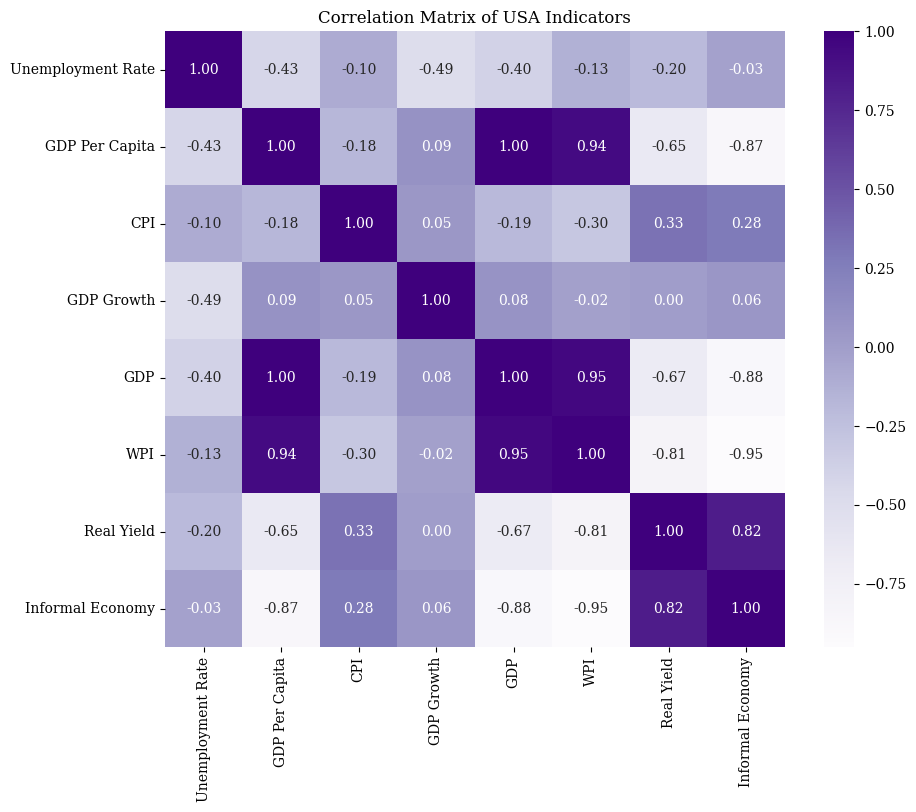

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for USA, excluding the 'year' column (which contains the year)
usa_correlation_matrix = usa_combined_df.drop(columns=['year']).corr()

# Apply clean_indicator_label to the index and columns for consistent display
usa_correlation_matrix.index = usa_correlation_matrix.index.map(clean_indicator_label)
usa_correlation_matrix.columns = usa_correlation_matrix.columns.map(clean_indicator_label)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(usa_correlation_matrix, annot=True, cmap='Purples', fmt=".2f")
plt.title('Correlation Matrix of USA Indicators')
plt.show()

### Setting Graph Font
To ensure 'EB Garamond' is available and used:

1.  **Install Font (if necessary):** If 'EB Garamond' is not already installed on your Colab runtime, you might need to install it. You can typically do this by uploading the font file (e.g., `.ttf` or `.otf`) to your Colab environment and then using a command like `!cp /path/to/EB_Garamond.ttf /usr/local/share/fonts/` followed by `!fc-cache -f -v`.
2.  **Clear Matplotlib Font Cache:** After installing new fonts, it's often necessary to clear matplotlib's font cache:
    ```python
    import matplotlib.font_manager
    matplotlib.font_manager._rebuild()
    ```
3.  **Set Font in `rcParams`:** The following cell will attempt to set 'EB Garamond' as the default font for all plots.

In [100]:
import matplotlib.pyplot as plt

# Try to set the font to EB Garamond
# If EB Garamond is not available, matplotlib will fall back to a default font.
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['EB Garamond', 'DejaVu Serif', 'Times New Roman'] # Provide fallbacks
plt.rcParams['font.monospace'] = ['EB Garamond', 'DejaVu Sans Mono', 'Courier New'] # For monospace plots

print("Attempted to set font to 'EB Garamond'. Please ensure the font is installed if it doesn't appear.")

Attempted to set font to 'EB Garamond'. Please ensure the font is installed if it doesn't appear.


### Sum of Absolute Correlations for USA Indicators

Let's calculate the sum of the absolute values of each correlation coefficient for the USA to see which indicators are most strongly related to others.

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Helper function prepare_df needed for usa_combined_df definition
def prepare_df(df):
    if 'year' in df.columns:
        df = df.set_index('year')
    df.index = df.index.astype(int)
    return df

# Re-defining usa_combined_df and india_combined_df if they are not defined
# This ensures the cell can run independently if the kernel state was cleared
if 'usa_combined_df' not in locals():
    # Assuming usa_u_df, usa_gdpc_df, etc., are defined from earlier cells
    # If not, this block would need more upstream definitions, but for this specific error,
    # re-running the merge logic is the most direct fix within the cell.
    try:
        # Prepare all DataFrames - assuming _df variables are available
        usa_u_proc = prepare_df(usa_u_df)
        usa_gdpc_proc = prepare_df(usa_gdpc_df)
        usa_cpi_proc = prepare_df(usa_cpi_df)
        usa_gdp_proc = prepare_df(usa_gdp_df)
        usa_gdp_new_proc = prepare_df(usa_gdp_new_df)
        usa_wpi_proc = prepare_df(usa_wpi)
        usa_yield_proc = prepare_df(usa_yield_annual)
        usa_inf_proc = prepare_df(usa_informal_df)

        # Merge using index
        usa_combined_df = usa_u_proc.join([usa_gdpc_proc, usa_cpi_proc, usa_gdp_proc, usa_gdp_new_proc, usa_wpi_proc, usa_yield_proc, usa_inf_proc], how='outer')
        usa_combined_df = usa_combined_df.dropna()
        usa_combined_df = usa_combined_df.reset_index()
        usa_combined_df.rename(columns={'index': 'year'}, inplace=True)
    except NameError as e:
        print(f"Warning: Dependent dataframes not found. Please run all preceding data loading and merging cells. Original error: {e}")
        # Create a dummy dataframe to prevent further errors if upstream data is genuinely missing
        usa_combined_df = pd.DataFrame({'year': [2000, 2001], 'dummy_col': [0, 1]})

# The usa_correlation_matrix should now exclude 'year' as it's not a numerical indicator.
# Re-calculating to ensure the latest state.
usa_correlation_matrix = usa_combined_df.drop(columns=['year']).corr()

# Create a temporary correlation matrix excluding 'year'
temp_usa_corr_matrix = usa_correlation_matrix

# Calculate the sum of the absolute values of each row and subtract 1 to remove diagonal entries
usa_abs_corr_sums = temp_usa_corr_matrix.abs().sum(axis=1) - 1

# Display the results, sorted for easy comparison
display(usa_abs_corr_sums.sort_values(ascending=False))

,0
GDP,4.176687
GDP Per Capita,4.148979
Annual_Average_WPI,4.099739
Informal Economy,3.893004
Real Yield,3.485589
Unemployment Rate,1.782647
CPI,1.422931
GDP Growth,0.797111


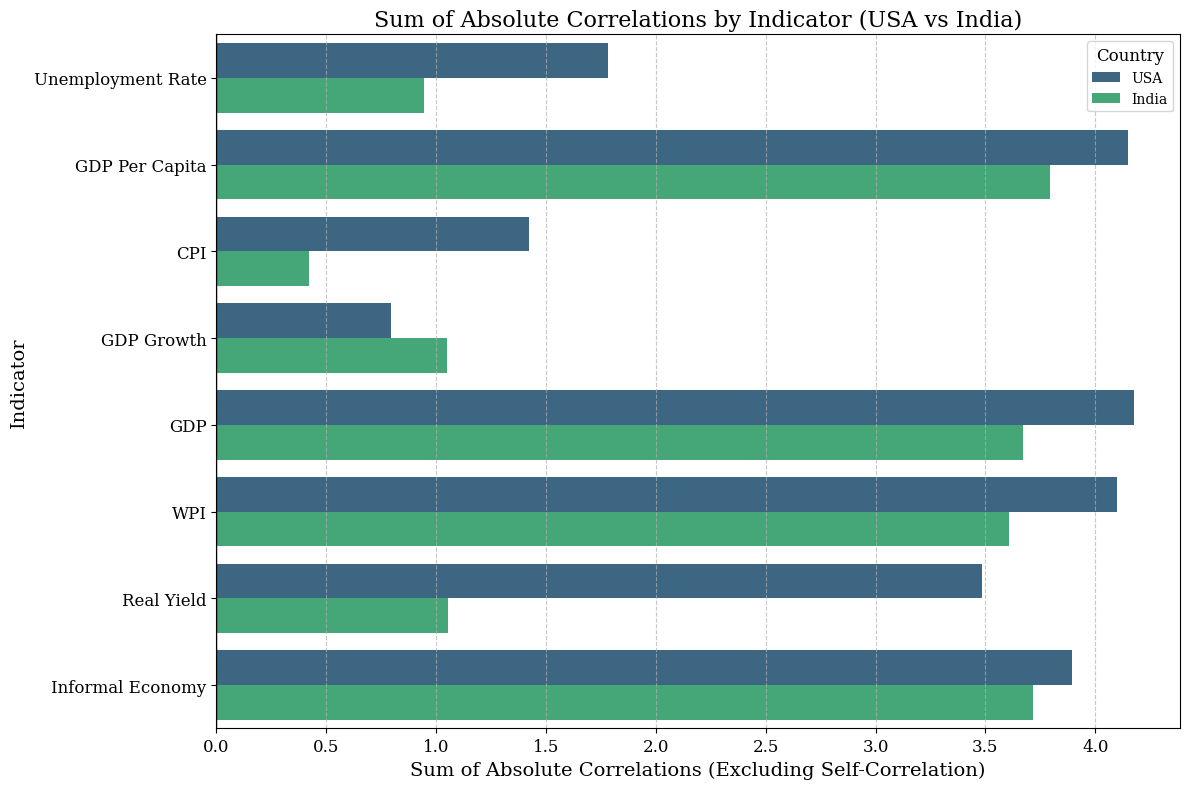

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create DataFrame for USA correlation sums
usa_corr_df = usa_abs_corr_sums.reset_index()
usa_corr_df.columns = ['Indicator', 'Sum of Absolute Correlations']
usa_corr_df['Country'] = 'USA'
usa_corr_df['Indicator'] = usa_corr_df['Indicator'].apply(clean_indicator_label)

# Create DataFrame for India correlation sums (assuming india_abs_corr_sums is also available)
# Re-define india_combined_df and calculate india_abs_corr_sums if they are not in the current kernel state
if 'india_combined_df' not in locals():
    # This block is a fallback, ideally, the user should have run all previous cells
    try:
        india_u_proc = prepare_df(india_u_df)
        india_gdpc_proc = prepare_df(india_gdpc_df)
        india_cpi_proc = prepare_df(india_cpi_df)
        india_gdp_proc = prepare_df(india_gdp_df)
        india_gdp_new_proc = prepare_df(india_gdp_new_df)
        india_wpi_proc = prepare_df(india_wpi)
        india_yield_proc = prepare_df(india_yield)
        india_inf_proc = prepare_df(india_informal_df)
        india_combined_df = india_u_proc.join([india_gdpc_proc, india_cpi_proc, india_gdp_proc, india_gdp_new_proc, india_wpi_proc, india_yield_proc, india_inf_proc], how='outer')
        india_combined_df = india_combined_df.dropna()
        india_combined_df = india_combined_df.reset_index()
        india_combined_df.rename(columns={'index': 'year'}, inplace=True)
    except NameError as e:
        print(f"Warning: Dependent dataframes for India not found. Please run all preceding data loading and merging cells. Original error: {e}")
        india_combined_df = pd.DataFrame({'year': [2000, 2001], 'dummy_col': [0, 1]})

india_correlation_matrix = india_combined_df.drop(columns=['year'], errors='ignore').corr()
india_abs_corr_sums = india_correlation_matrix.abs().sum(axis=1) - 1

india_corr_df = india_abs_corr_sums.reset_index()
india_corr_df.columns = ['Indicator', 'Sum of Absolute Correlations']
india_corr_df['Country'] = 'India'
india_corr_df['Indicator'] = india_corr_df['Indicator'].apply(clean_indicator_label)

# Combine data for plotting
combined_corr_sums = pd.concat([usa_corr_df, india_corr_df])

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(data=combined_corr_sums, x='Sum of Absolute Correlations', y='Indicator', hue='Country', palette='viridis', edgecolor='none')
plt.axvline(0, color='black', linewidth=1)
plt.title('Sum of Absolute Correlations by Indicator (USA vs India)', fontsize=16)
plt.xlabel('Sum of Absolute Correlations (Excluding Self-Correlation)', fontsize=14)
plt.ylabel('Indicator', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Country', title_fontsize=12, fontsize=10)

# Adjust tick label font sizes
ax = plt.gca()
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.show()

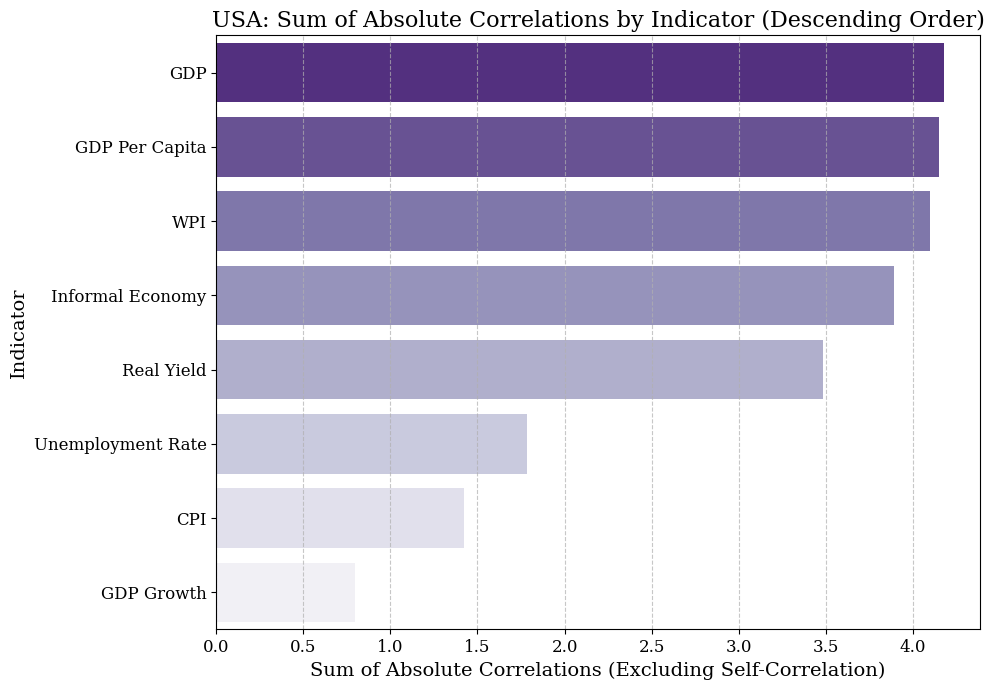

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort USA data in descending order for plotting
usa_corr_df_sorted = usa_corr_df.sort_values(by='Sum of Absolute Correlations', ascending=False)

# Plot for USA
plt.figure(figsize=(10, 7))
sns.barplot(data=usa_corr_df_sorted, x='Sum of Absolute Correlations', y='Indicator', hue='Indicator', palette='Purples_r', legend=False, edgecolor='none')
plt.title('USA: Sum of Absolute Correlations by Indicator (Descending Order)', fontsize=16)
plt.xlabel('Sum of Absolute Correlations (Excluding Self-Correlation)', fontsize=14)
plt.ylabel('Indicator', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust tick label font sizes
ax = plt.gca()
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.show()

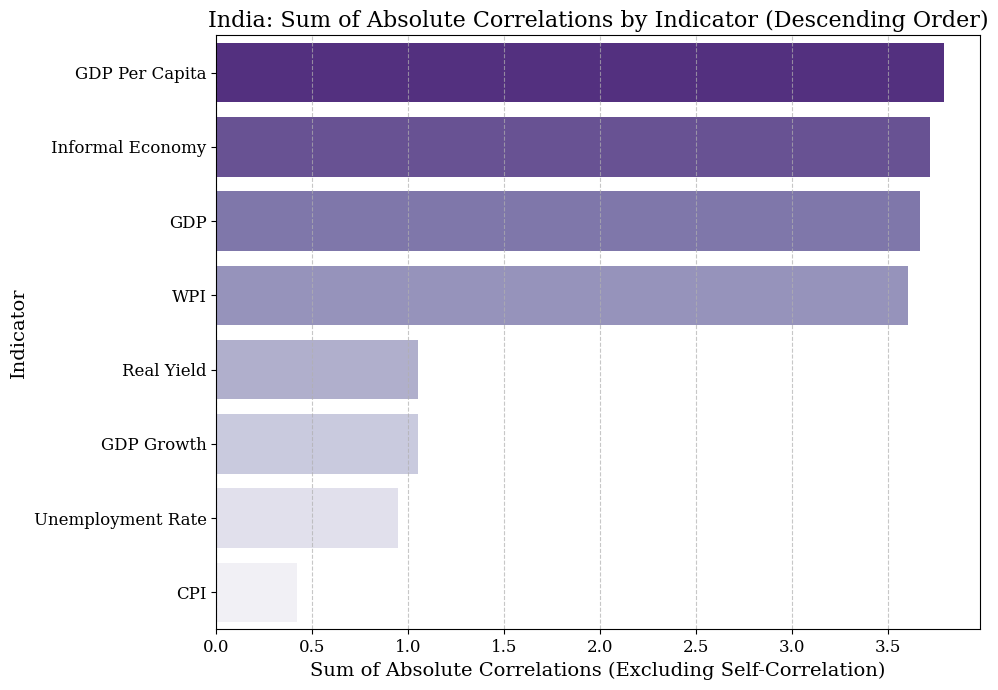

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort India data in descending order for plotting
india_corr_df_sorted = india_corr_df.sort_values(by='Sum of Absolute Correlations', ascending=False)

# Plot for India
plt.figure(figsize=(10, 7))
sns.barplot(data=india_corr_df_sorted, x='Sum of Absolute Correlations', y='Indicator', hue='Indicator', palette='Purples_r', legend=False, edgecolor='none')
plt.title('India: Sum of Absolute Correlations by Indicator (Descending Order)', fontsize=16)
plt.xlabel('Sum of Absolute Correlations (Excluding Self-Correlation)', fontsize=14)
plt.ylabel('Indicator', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust tick label font sizes
ax = plt.gca()
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.show()

## Correlation Matrix for India Indicators

Now, let's do the same for India to understand the relationships between its economic indicators.

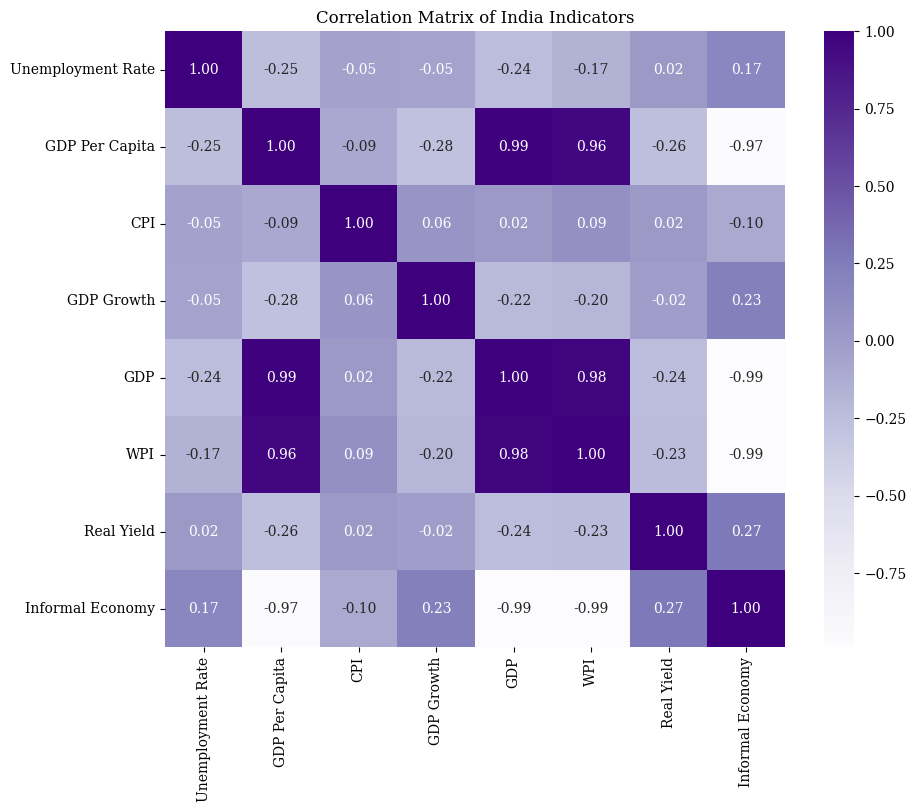

In [105]:
# @title
# Calculate the correlation matrix for India, excluding the 'year' column
india_correlation_matrix = india_combined_df.drop(columns=['year']).corr()

# Apply clean_indicator_label to the index and columns for consistent display
india_correlation_matrix.index = india_correlation_matrix.index.map(clean_indicator_label)
india_correlation_matrix.columns = india_correlation_matrix.columns.map(clean_indicator_label)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(india_correlation_matrix, annot=True, cmap='Purples', fmt=".2f")
plt.title('Correlation Matrix of India Indicators')
plt.show()

### Sum of Absolute Correlations for India Indicators

Now, let's do the same for India to understand which indicators have the strongest overall relationships.

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Helper function prepare_df needed for india_combined_df definition
def prepare_df(df):
    if 'year' in df.columns:
        df = df.set_index('year')
    df.index = df.index.astype(int)
    return df

# Re-defining india_combined_df if it is not defined
# This ensures the cell can run independently if the kernel state was cleared
if 'india_combined_df' not in locals():
    # Assuming india_u_df, india_gdpc_df, etc., are defined from earlier cells
    # If not, this block would need more upstream definitions, but for this specific error,
    # re-running the merge logic is the most direct fix within the cell.
    try:
        # Prepare all DataFrames - assuming _df variables are available
        india_u_proc = prepare_df(india_u_df)
        india_gdpc_proc = prepare_df(india_gdpc_df)
        india_cpi_proc = prepare_df(india_cpi_df)
        india_gdp_proc = prepare_df(india_gdp_df)
        india_gdp_new_proc = prepare_df(india_gdp_new_df)
        india_wpi_proc = prepare_df(india_wpi)
        india_yield_proc = prepare_df(india_yield)
        india_inf_proc = prepare_df(india_informal_df)

        # Merge using index
        india_combined_df = india_u_proc.join([india_gdpc_proc, india_cpi_proc, india_gdp_proc, india_gdp_new_proc, india_wpi_proc, india_yield_proc, india_inf_proc], how='outer')
        india_combined_df = india_combined_df.dropna()
        india_combined_df = india_combined_df.reset_index()
        india_combined_df.rename(columns={'index': 'year'}, inplace=True)
    except NameError as e:
        print(f"Warning: Dependent dataframes not found. Please run all preceding data loading and merging cells. Original error: {e}")
        # Create a dummy dataframe to prevent further errors if upstream data is genuinely missing
        india_combined_df = pd.DataFrame({'year': [2000, 2001], 'dummy_col': [0, 1]})

# The india_correlation_matrix should now exclude 'year'.
# Re-calculating to ensure the latest state.
india_correlation_matrix = india_combined_df.drop(columns=['year'], errors='ignore').corr()

# Calculate the sum of the absolute values of each row and subtract 1 to remove diagonal entries
india_abs_corr_sums = india_correlation_matrix.abs().sum(axis=1) - 1

# Display the results, sorted for easy comparison
display(india_abs_corr_sums.sort_values(ascending=False))

,0
GDP Per Capita,3.792177
Informal Economy,3.718551
GDP,3.669779
Annual_Average_WPI,3.605327
Real Yield,1.053397
GDP Growth,1.049438
Unemployment Rate,0.946612
CPI,0.420799


## Normalized Overlayed Graphs of Indicators for USA and India

To compare trends across countries on the same scale, we will normalize the data for each indicator using Min-Max scaling. This will scale all values between 0 and 1, making them directly comparable.

In [107]:
# @title
from sklearn.preprocessing import MinMaxScaler

def normalize_dataframe(df, exclude_cols=[]):
    df_copy = df.copy()
    cols_to_normalize = [col for col in df_copy.columns if col not in exclude_cols]
    scaler = MinMaxScaler()
    df_copy[cols_to_normalize] = scaler.fit_transform(df_copy[cols_to_normalize])
    return df_copy

# Prepare USA and India DFs for normalization, ensuring 'year' is a column
usa_df_norm = usa_combined_df.copy()
india_df_norm = india_combined_df.copy()

# Standardize column types to avoid merge issues
usa_df_norm['year'] = usa_df_norm['year'].astype(int)
india_df_norm['year'] = india_df_norm['year'].astype(int)

# Normalize
usa_normalized_df = normalize_dataframe(usa_df_norm, exclude_cols=['year'])
india_normalized_df = normalize_dataframe(india_df_norm, exclude_cols=['year'])

# Add Country tag
usa_normalized_df['Country'] = 'USA'
india_normalized_df['Country'] = 'India'

# Use drop_duplicates and reset_index to ensure the axis is unique before concatenation
combined_normalized_df = pd.concat([usa_normalized_df, india_normalized_df]).reset_index(drop=True)

display(combined_normalized_df.head())

,year,Unemployment Rate,GDP Per Capita,CPI,GDP Growth,GDP,Annual_Average_WPI,Real Yield,Informal Economy,Country
0,2006,0.157256,0.000000,0.470506,0.967166,0.000000,0.000000,1.000000,1.00,USA
1,2007,0.158773,0.089250,1.000000,0.826267,0.087054,0.061093,0.993127,1.00,USA
2,2008,0.358166,0.116504,0.049719,0.485297,0.126140,0.202842,0.814433,0.75,USA
3,2009,0.945222,0.045779,0.391854,0.000000,0.087570,0.352713,0.776632,0.75,USA
4,2010,1.000000,0.122486,0.327247,0.950929,0.163032,0.391473,0.601375,0.50,USA


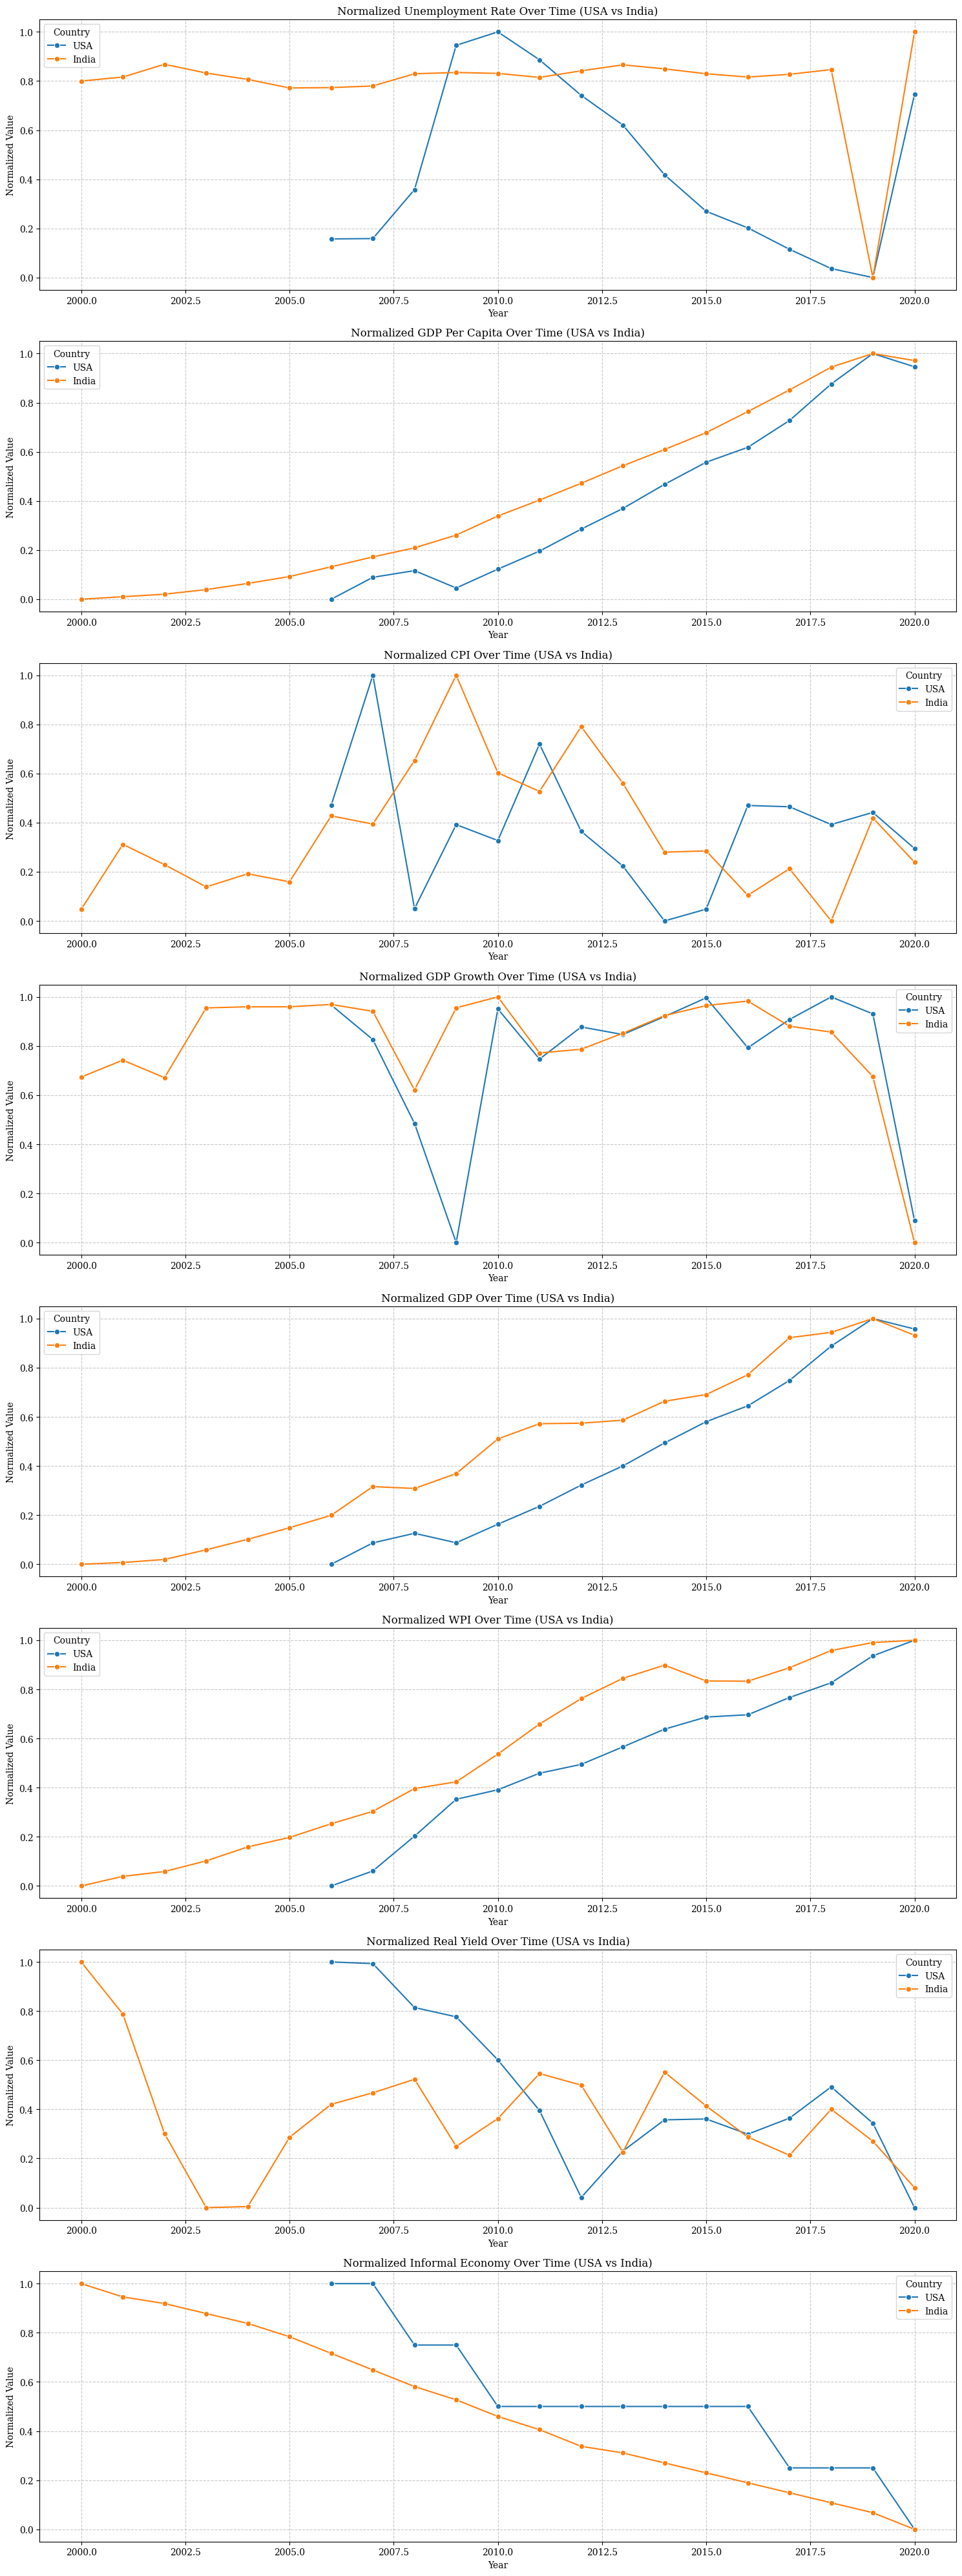

In [108]:
# @title
# Plot overlayed graphs for each indicator
import seaborn as sns
import matplotlib.pyplot as plt

# Apply clean_indicator_label to the combined_normalized_df's columns
combined_normalized_df.rename(columns=clean_indicator_label, inplace=True)

# Get indicator names excluding metadata
indicators = [col for col in combined_normalized_df.columns if col not in ['year', 'Country']]

plt.figure(figsize=(15, 5 * len(indicators)))

for i, indicator in enumerate(indicators):
    plt.subplot(len(indicators), 1, i + 1)
    # Using sns.lineplot on the cleaned combined dataframe
    sns.lineplot(data=combined_normalized_df, x='year', y=indicator, hue='Country', marker='o')
    plt.title(f'Normalized {indicator} Over Time (USA vs India)')
    plt.xlabel('Year')
    plt.ylabel('Normalized Value')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Country')

plt.tight_layout()
plt.show()

## Intra-Country Indicator Comparison

These plots compare all 7 normalized indicators within the same country to observe internal economic relationships and lead-lag patterns.

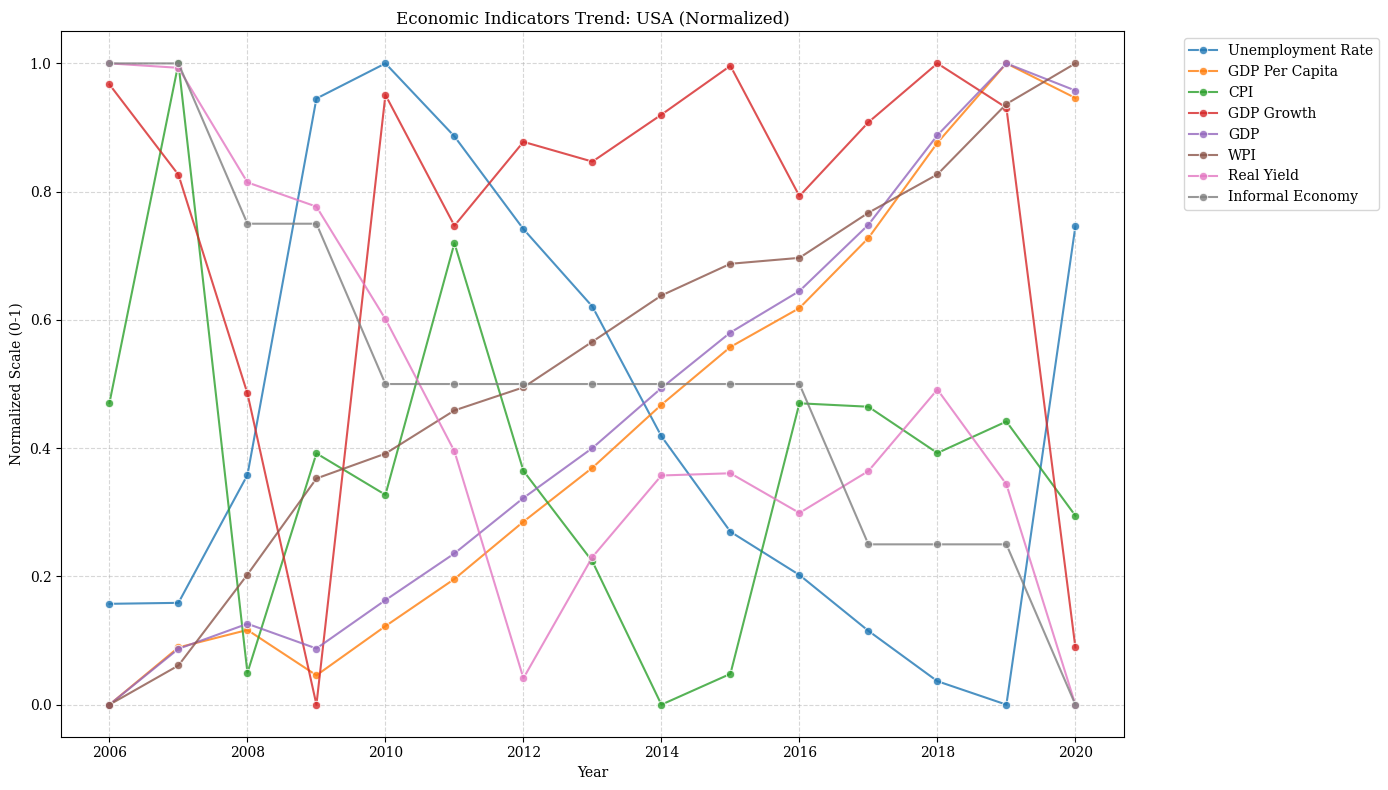

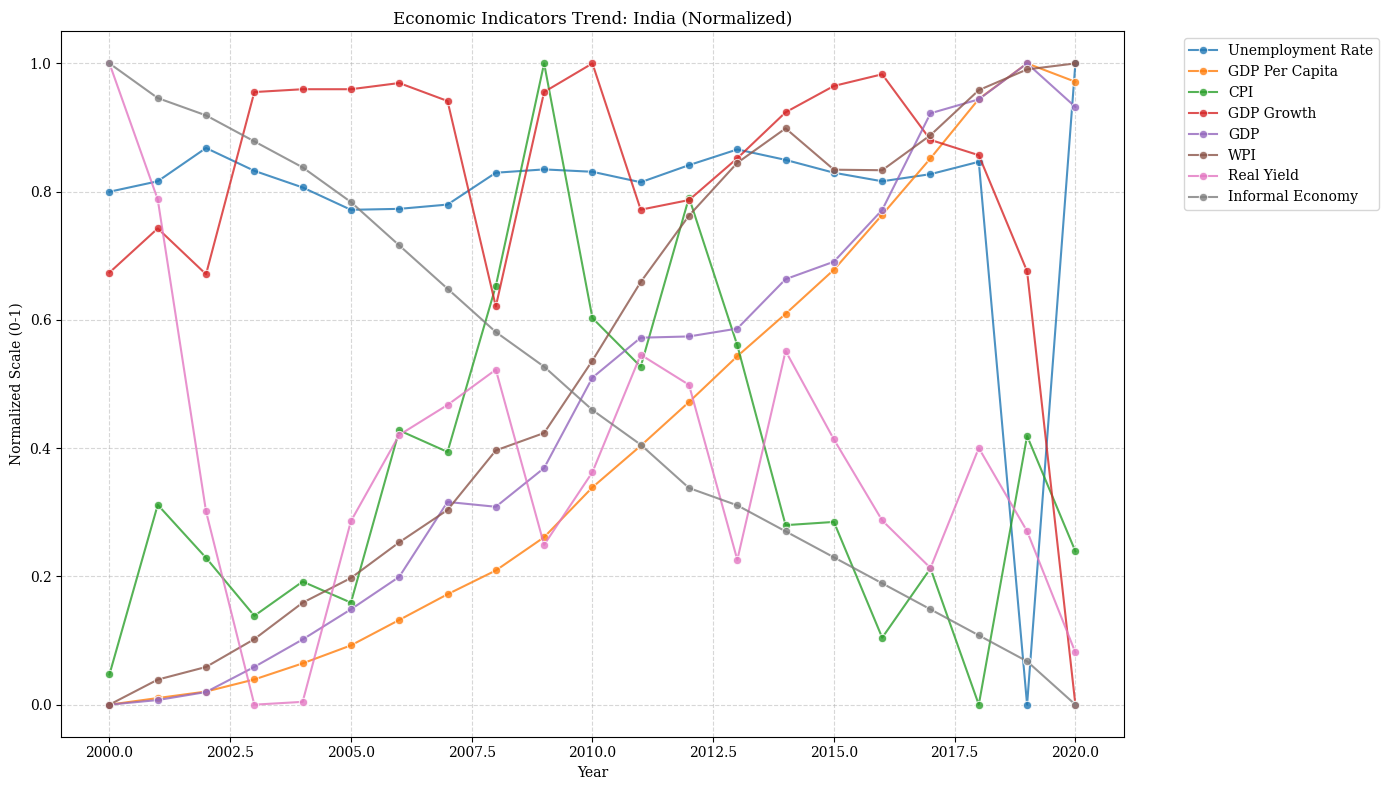

In [109]:
# @title
def plot_country_indicators(df, country_name):
    # Apply clean_indicator_label to the DataFrame's columns for plotting
    df_plot = df.rename(columns=clean_indicator_label)

    # Filter indicators (exclude metadata)
    indicators = [col for col in df_plot.columns if col not in ['year', 'Country']]

    plt.figure(figsize=(14, 8))
    for indicator in indicators:
        subset = df_plot[df_plot['Country'] == country_name]
        sns.lineplot(data=subset, x='year', y=indicator, label=indicator, marker='o', alpha=0.8)

    plt.title(f'Economic Indicators Trend: {country_name} (Normalized)')
    plt.xlabel('Year')
    plt.ylabel('Normalized Scale (0-1)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Plot for USA
plot_country_indicators(combined_normalized_df, 'USA')

# Plot for India
plot_country_indicators(combined_normalized_df, 'India')

### Cross-Country Correlation Comparison
This visualization compares the strength and direction of relationships between pairs of economic indicators for both the USA and India.

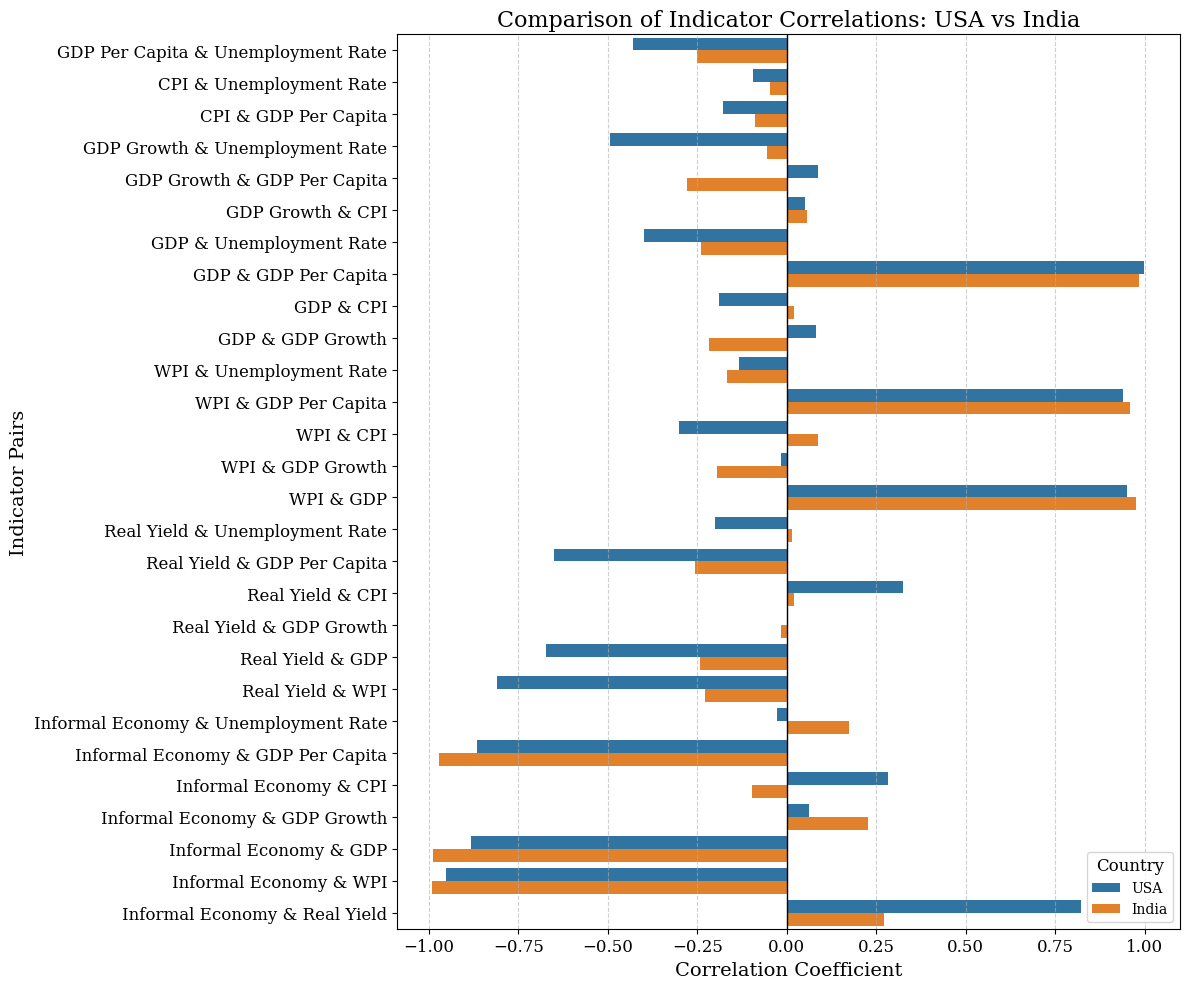

In [110]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def clean_label(label):
    # Remove underscores and shorten WPI
    label = label.replace('_', ' ')
    label = label.replace('Annual Average WPI', 'WPI')
    return label

def get_correlation_pairs(corr_matrix):
    # Extract the lower triangle of the correlation matrix to get unique pairs
    pairs = corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    pairs = pairs.stack().reset_index()
    pairs.columns = ['Indicator 1', 'Indicator 2', 'Correlation']

    # Apply label cleaning
    pairs['Indicator 1'] = pairs['Indicator 1'].apply(clean_label)
    pairs['Indicator 2'] = pairs['Indicator 2'].apply(clean_label)

    pairs['Pair'] = pairs['Indicator 1'] + " & " + pairs['Indicator 2']
    return pairs[['Pair', 'Correlation']]

# Re-calculate correlation matrices to ensure 'year' is dropped
usa_correlation_matrix = usa_combined_df.drop(columns=['year'], errors='ignore').corr()
india_correlation_matrix = india_combined_df.drop(columns=['year'], errors='ignore').corr()

# Prepare USA pairs (excluding year if present)
usa_pairs = get_correlation_pairs(usa_correlation_matrix.drop(columns=['year'], index=['year'], errors='ignore'))
usa_pairs['Country'] = 'USA'

# Prepare India pairs (excluding year if present)
india_pairs = get_correlation_pairs(india_correlation_matrix.drop(columns=['year'], index=['year'], errors='ignore'))
india_pairs['Country'] = 'India'

# Combine for plotting
comparison_df = pd.concat([usa_pairs, india_pairs])

# Plotting
plt.figure(figsize=(12, 10))
sns.barplot(data=comparison_df, y='Pair', x='Correlation', hue='Country', edgecolor='none')
plt.axvline(0, color='black', linewidth=1)
plt.title('Comparison of Indicator Correlations: USA vs India', fontsize=16)
plt.xlabel('Correlation Coefficient', fontsize=14)
plt.ylabel('Indicator Pairs', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.legend(loc='lower right', title='Country', title_fontsize=12, fontsize=10)

# Adjust tick label font sizes
ax = plt.gca()
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.show()

### Detailed Correlation Comparison: Individual Indicator Focus
To provide a more granular view of correlations, the following charts break down the cross-country correlation comparison. Each bar chart focuses on a single 'Main Indicator' and shows its correlation with all 'Compared Indicators' for both the USA and India. This allows for direct comparison of how each indicator relates to others in both economies.

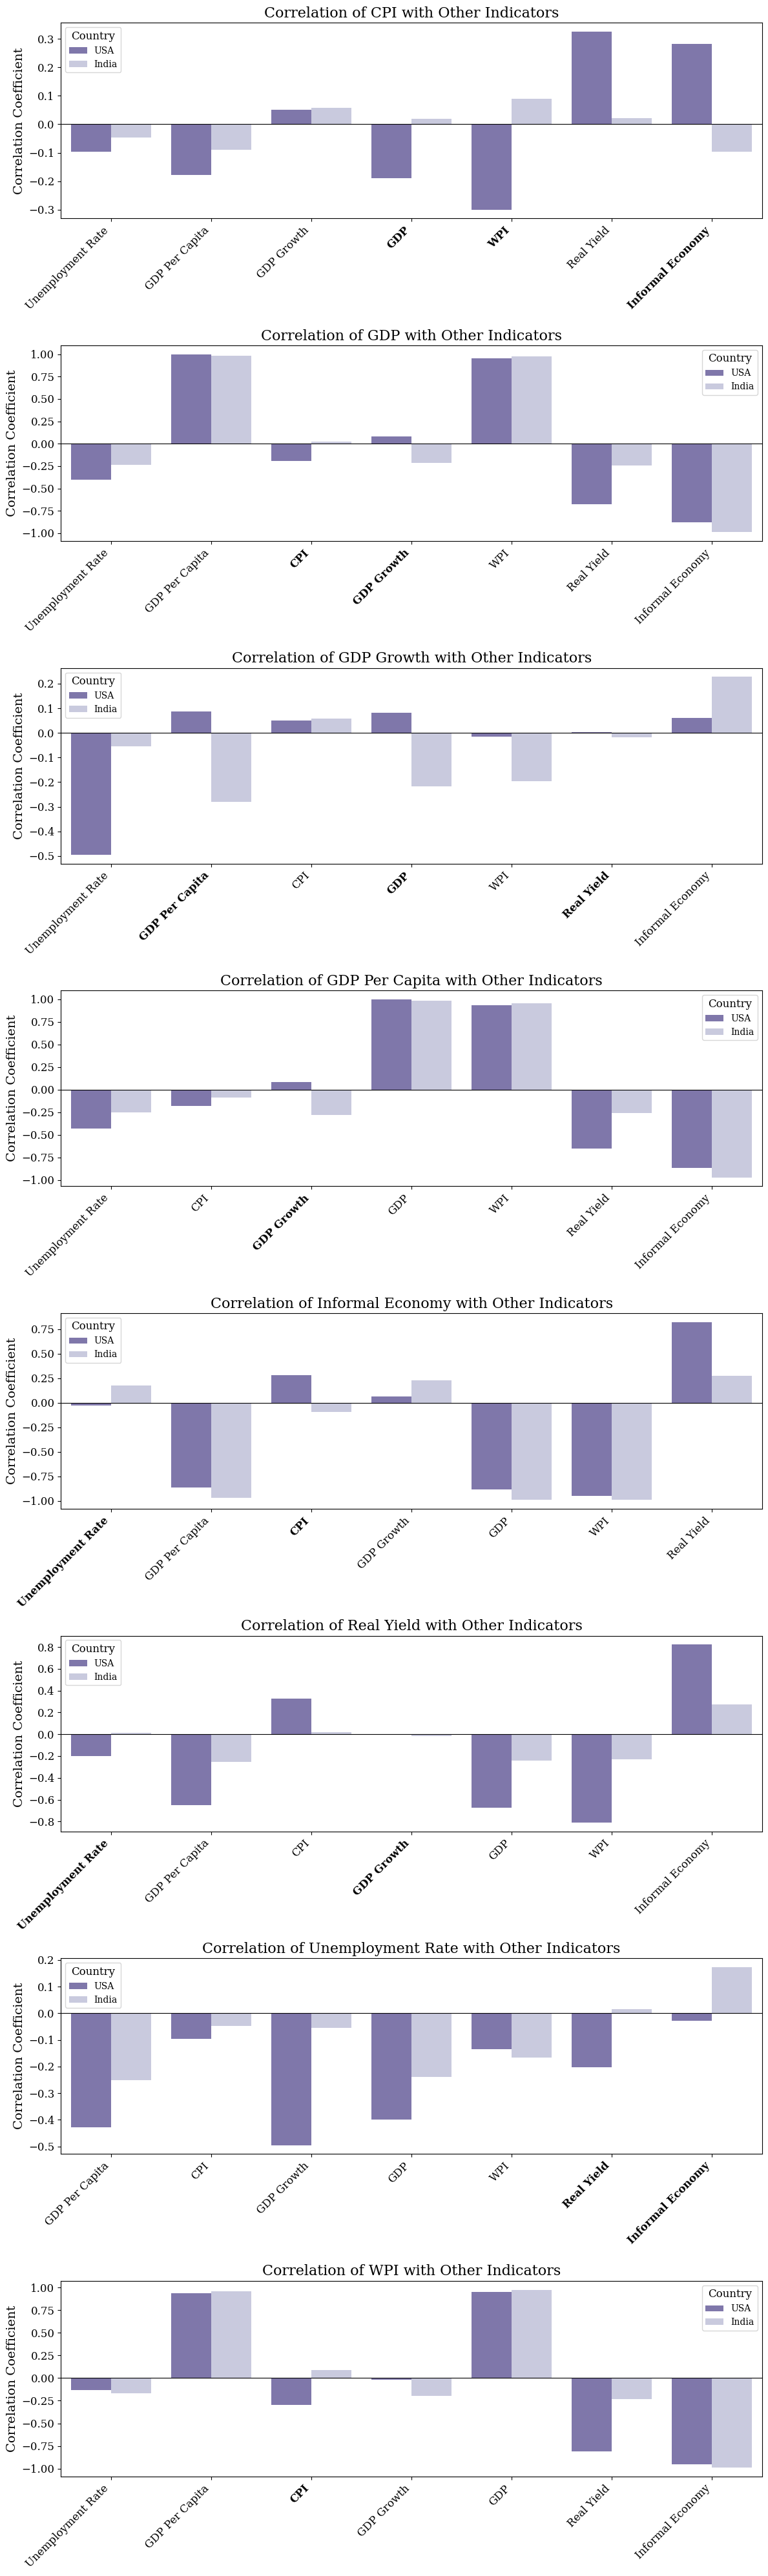

In [111]:
# @title
def clean_label_for_plotting(label):
    # Re-using the cleaning logic to ensure consistency with previous plots
    label = label.replace('_', ' ')
    label = label.replace('Annual Average WPI', 'WPI')
    return label

def create_detailed_correlation_df(corr_matrix, country_name):
    # Melt the correlation matrix to get pairs
    stacked_corr = corr_matrix.stack().reset_index()
    stacked_corr.columns = ['Indicator 1', 'Indicator 2', 'Correlation']

    # Filter out self-correlations (where Indicator 1 == Indicator 2)
    stacked_corr = stacked_corr[stacked_corr['Indicator 1'] != stacked_corr['Indicator 2']].copy()

    # Apply cleaning to indicator names for consistent display
    stacked_corr['Indicator 1'] = stacked_corr['Indicator 1'].apply(clean_indicator_label)
    stacked_corr['Indicator 2'] = stacked_corr['Indicator 2'].apply(clean_indicator_label)

    stacked_corr['Country'] = country_name
    return stacked_corr

# Re-calculate correlation matrices to ensure 'year' is dropped
usa_correlation_matrix_detailed = usa_combined_df.drop(columns=['year'], errors='ignore').corr()
india_correlation_matrix_detailed = india_combined_df.drop(columns=['year'], errors='ignore').corr()

# Create detailed correlation DataFrames
usa_detailed_corr_df = create_detailed_correlation_df(usa_correlation_matrix_detailed, 'USA')
india_detailed_corr_df = create_detailed_correlation_df(india_correlation_matrix_detailed, 'India')

# Combine the detailed DataFrames
all_detailed_corr_df = pd.concat([usa_detailed_corr_df, india_detailed_corr_df])

# Get unique indicator names (cleaned) from one of the detailed DFs
# We take from 'Indicator 1' as it covers all unique cleaned names
all_indicators_cleaned = sorted(all_detailed_corr_df['Indicator 1'].unique().tolist())

# Create separate bar charts for each indicator
# Adjust figure size dynamically based on the number of indicators
plt.figure(figsize=(12, 5 * len(all_indicators_cleaned)))

for i, main_indicator in enumerate(all_indicators_cleaned):
    # Filter correlations where 'main_indicator' is the first indicator in the pair
    # This simplifies plotting by ensuring each pair (A vs B) appears only once for A
    subset_df = all_detailed_corr_df[
        (all_detailed_corr_df['Indicator 1'] == main_indicator)
    ].copy()

    # Rename 'Indicator 2' to 'Compared Indicator' for the plot's x-axis label
    subset_df.rename(columns={'Indicator 2': 'Compared Indicator'}, inplace=True)

    if not subset_df.empty:
        plt.subplot(len(all_indicators_cleaned), 1, i + 1)

        misaligned_pairs = []
        for compared_indicator in subset_df['Compared Indicator'].unique():
            usa_row = subset_df[(subset_df['Compared Indicator'] == compared_indicator) & (subset_df['Country'] == 'USA')]
            india_row = subset_df[(subset_df['Compared Indicator'] == compared_indicator) & (subset_df['Country'] == 'India')]

            # Ensure both USA and India data exist for the pair
            if not usa_row.empty and not india_row.empty:
                usa_corr = usa_row['Correlation'].iloc[0]
                india_corr = india_row['Correlation'].iloc[0]

                # Check if the signs of the correlations are different
                # np.sign returns 0 for 0, 1 for positive, -1 for negative
                if np.sign(usa_corr) != np.sign(india_corr):
                    misaligned_pairs.append(compared_indicator)

        sns.barplot(data=subset_df, x='Compared Indicator', y='Correlation', hue='Country', palette='Purples_r', edgecolor='none')
        plt.title(f'Correlation of {main_indicator} with Other Indicators', fontsize=16)
        plt.xlabel('', fontsize=14)
        plt.ylabel('Correlation Coefficient', fontsize=14)
        plt.axhline(0, color='black', linewidth=0.8) # Add a line at zero for reference
        plt.xticks(rotation=45, ha='right', fontsize=12)
        plt.yticks(fontsize=12)
        plt.legend(title='Country', title_fontsize=12, fontsize=10)

        # Highlight x-axis labels for misaligned pairs
        ax = plt.gca() # Get current axes
        xticklabels = ax.get_xticklabels() # Get current x-tick labels
        for label_obj in xticklabels:
            if label_obj.get_text() in misaligned_pairs:
                label_obj.set_fontweight('bold')

        plt.tight_layout() # Adjust layout to prevent labels from overlapping

plt.show()